# Getting Started

In [1]:
import matplotlib.pyplot as plt
import pyvista as pv

from epentry import Box

pv.set_jupyter_backend('static') # change to 'html' for interactive plots

**Note:** Most computationally intensive methods are implemented using Numba, which compiles functions the first time they are called. As a result, the first run of any such method is always slower than subsequent runs.

## Generate a Box with Particles

Generating a box of particles is a two-step process:

* Initialize the box with the _target_ particle radii, volume fractions, and total number of particles.
* Populate the box with a particle configuration using one of the methods below.

| Method                           | Arrangement | Size Distribution | Maximum packing fraction (%) |
|----------------------------------|:-----------:|:-----------------:|:----------------------------:|
| Simple Cubic (SC)                |   Lattice   |     Monomodal     |              52              |
| Body-Centered Cubic (BCC)        |   Lattice   |     Monomodal     |              68              |
| Face-Centered Cubic (FCC)        |   Lattice   |     Monomodal     |              74              |
| Random Sequential Addition (RSA) |    Random   |     Multimodal    |             ~ 38             |
| Monte-Carlo Relaxation (MCR)     |    Random   |     Monomodal     |             ~ 60             |
| Force-Biased Relaxation (FBR)    |    Random   |     Multimodal    |          "Realistic"         |

### Lattice Configurations

Lattice-type generation methods only apply to _monomodal_ systems. Let's create and visualize a unit-cell box with a target volume fraction of 50% for each of the three supported lattice structures.

Box(
    rs         = [1.],
    vfs_target = [0.5],
    vfs        = [0.5],
    Nt_target  = 1,
    Nt         = 1,
    Ns         = [1],
    length     = 2.0309825951265186,
    method     = Simple Cubic,
    periodic   = True,
    success    = True,
)



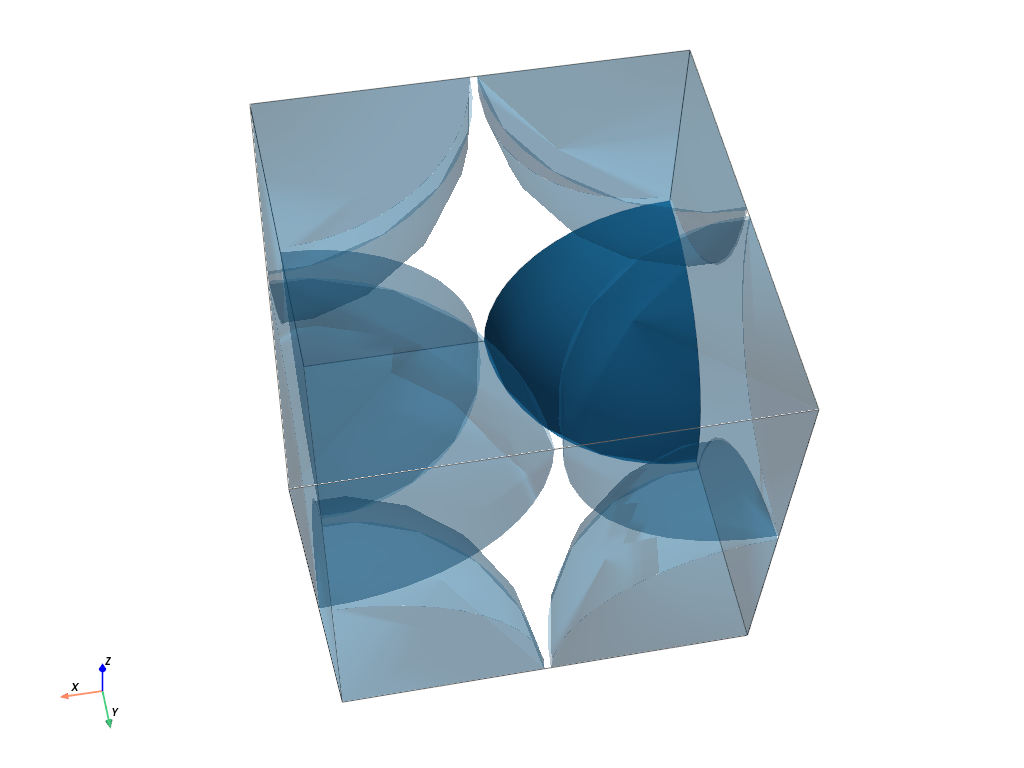

Box(
    rs         = [1.],
    vfs_target = [0.5],
    vfs        = [0.5],
    Nt_target  = 1,
    Nt         = 2,
    Ns         = [2],
    length     = 2.558877723570017,
    method     = Body-Centered Cubic,
    periodic   = True,
    success    = True,
)



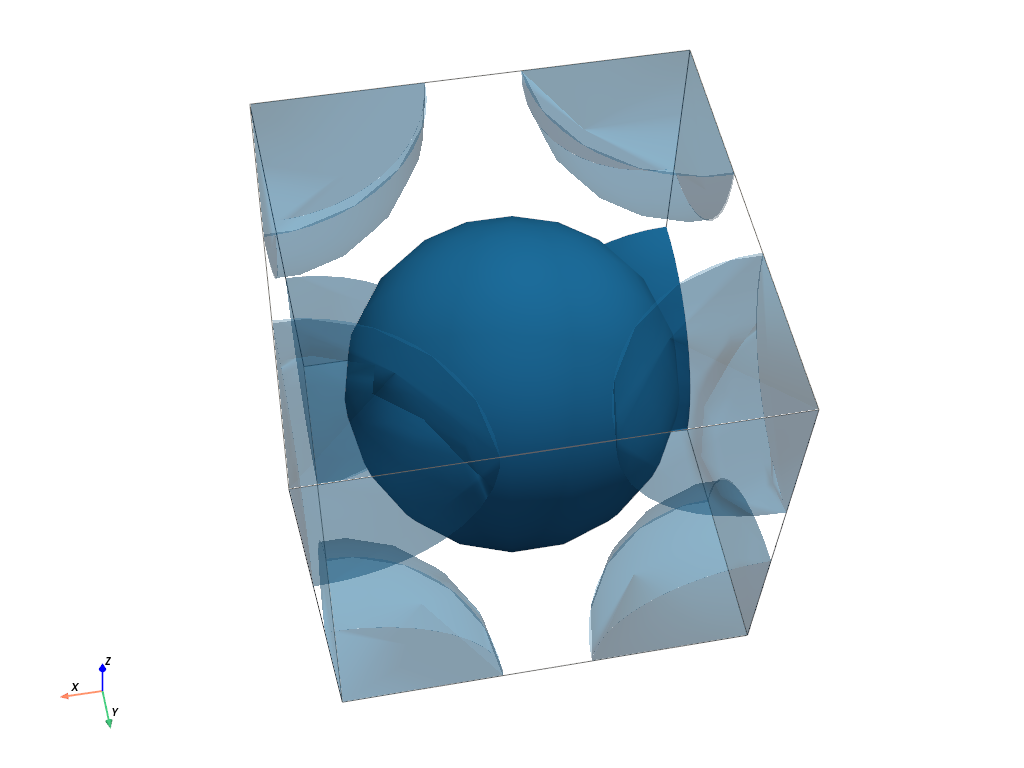

Box(
    rs         = [1.],
    vfs_target = [0.5],
    vfs        = [0.5],
    Nt_target  = 1,
    Nt         = 4,
    Ns         = [4],
    length     = 3.223983908032939,
    method     = Face-Centered Cubic,
    periodic   = True,
    success    = True,
)



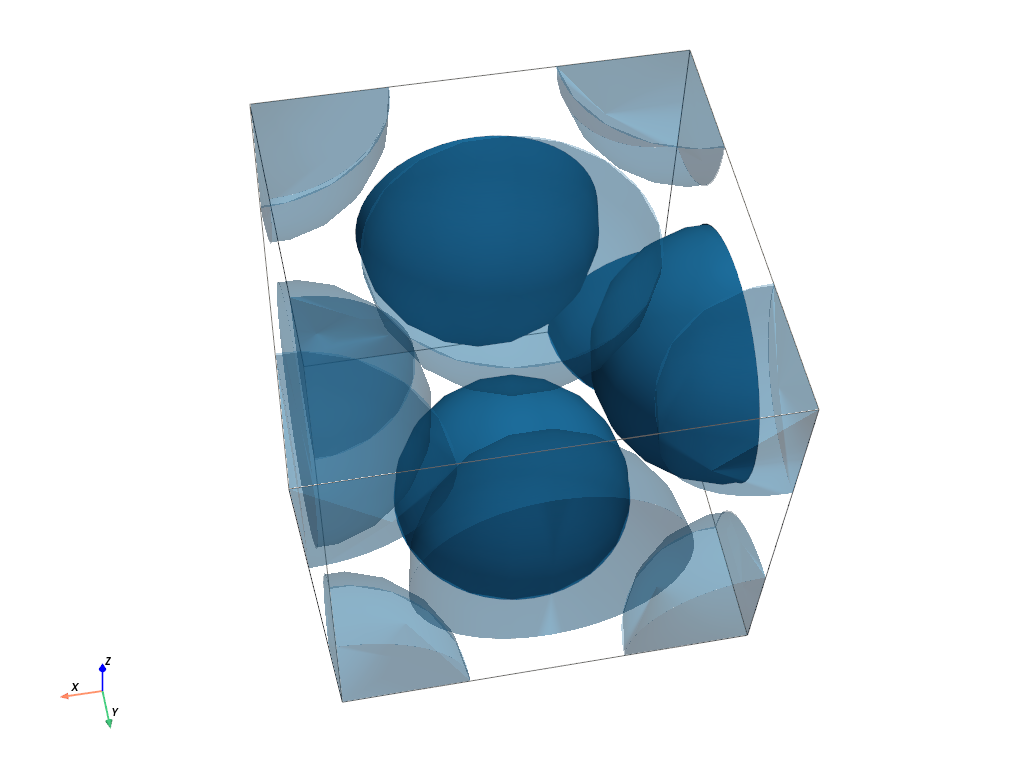

In [2]:
for method in ["SC", "BCC", "FCC"]:
    box = Box(
        rs=[1.0],
        vfs=[0.50],
        Nt=1,
    )
    box.generate_particles(method=method)
    print(box)
    box.plot(backend="pyvista", clip=True).show()

### Random Monomodal Configurations

For monomodal random distributions, we can use any of the three available methods (RSA, MCR, or FBR), keeping in mind their respective jamming limits. At a volume fraction of 30%, all methods work.

Box(
    rs         = [1.],
    vfs_target = [0.3],
    vfs        = [0.3],
    Nt_target  = 100,
    Nt         = 100,
    Ns         = [100],
    length     = 11.17692795479829,
    method     = Random Sequential Addition,
    periodic   = True,
    success    = True,
)



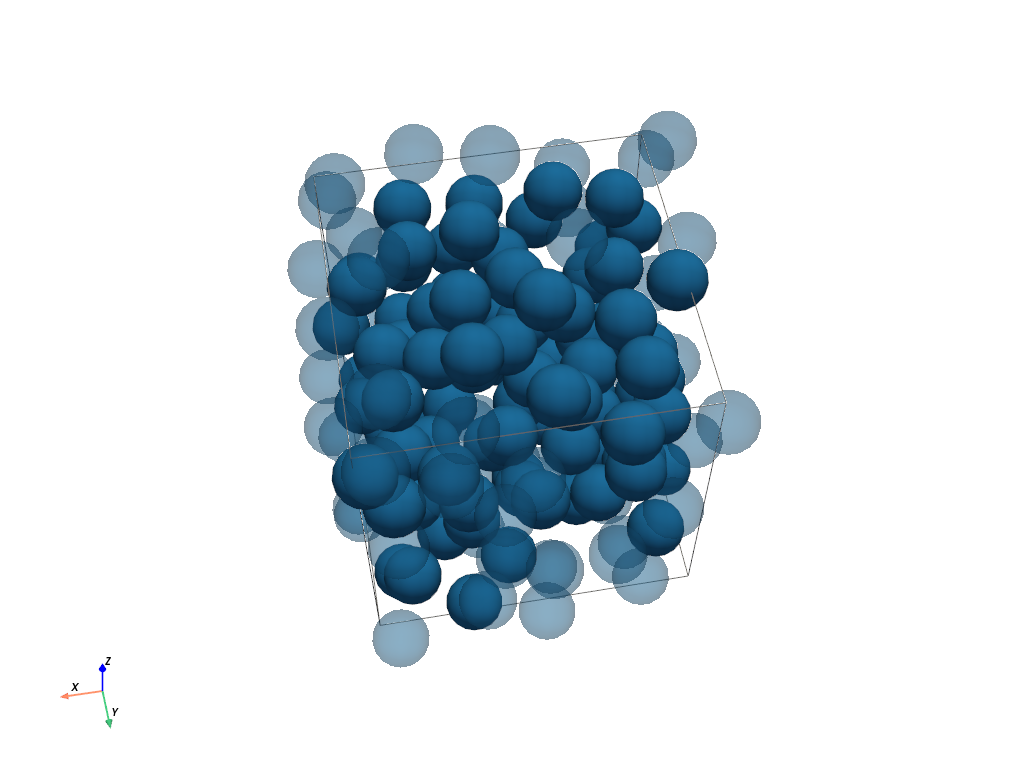

Box(
    rs         = [1.],
    vfs_target = [0.3],
    vfs        = [0.3],
    Nt_target  = 100,
    Nt         = 128,
    Ns         = [128],
    length     = 12.135540055966624,
    method     = Monte-Carlo Relaxation,
    periodic   = True,
    success    = True,
)



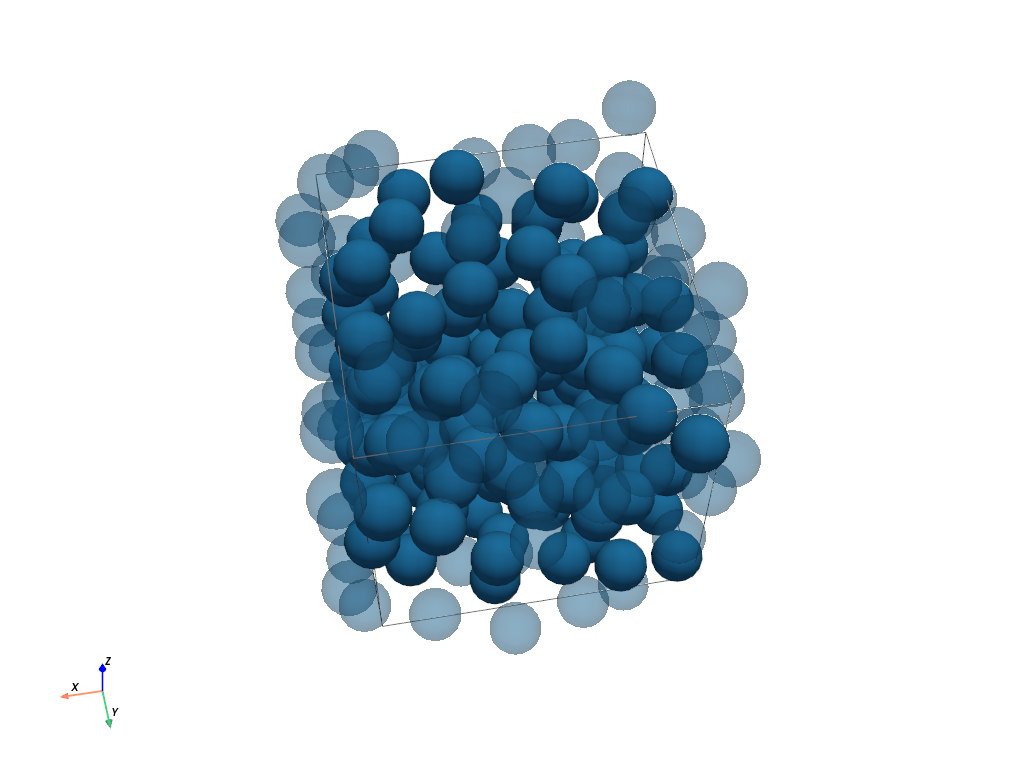

Box(
    rs         = [1.],
    vfs_target = [0.3],
    vfs        = [0.3],
    Nt_target  = 100,
    Nt         = 100,
    Ns         = [100],
    length     = 11.17692795479829,
    method     = Force-Biased Relaxation,
    periodic   = True,
    success    = True,
)



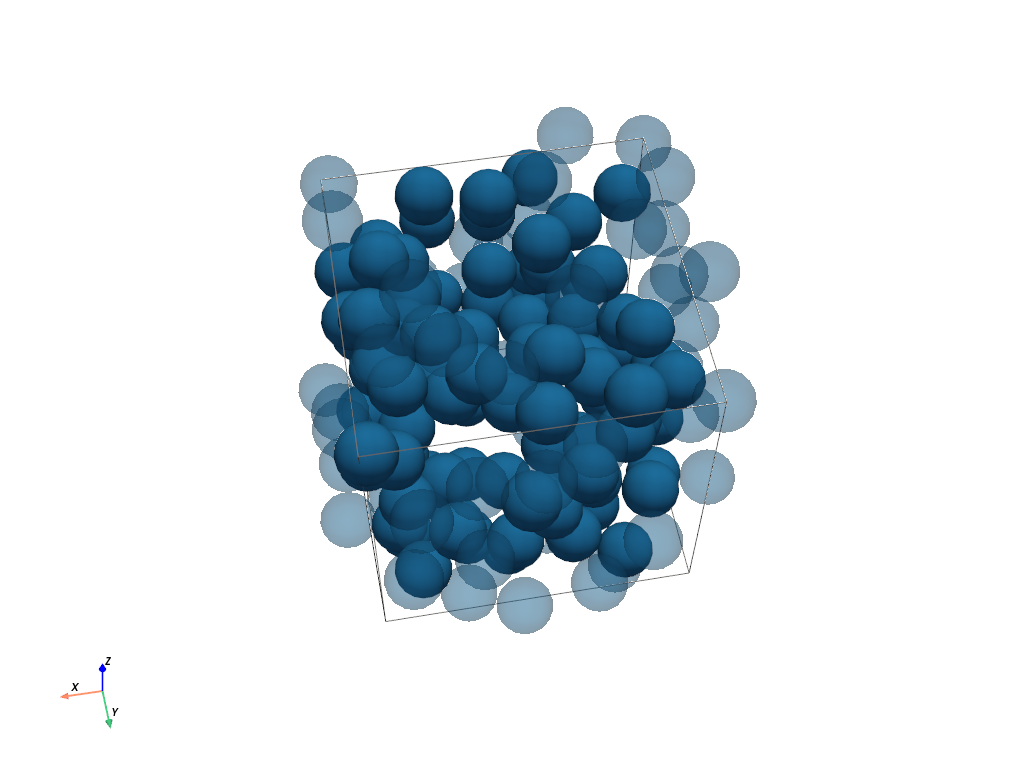

In [3]:
for method in ["RSA", "MCR", "FBR"]:
    box = Box(
        rs=[1.0],
        vfs=[0.30],
        Nt=100,
    )
    box.generate_particles(method=method)
    print(box)
    box.plot(backend="pyvista").show()

For dense random packings, one must use MCR or FBR.

Box(
    rs         = [1.],
    vfs_target = [0.6],
    vfs        = [0.6],
    Nt_target  = 200,
    Nt         = 200,
    Ns         = [200],
    length     = 11.17692795479829,
    method     = Force-Biased Relaxation,
    periodic   = True,
    success    = True,
)



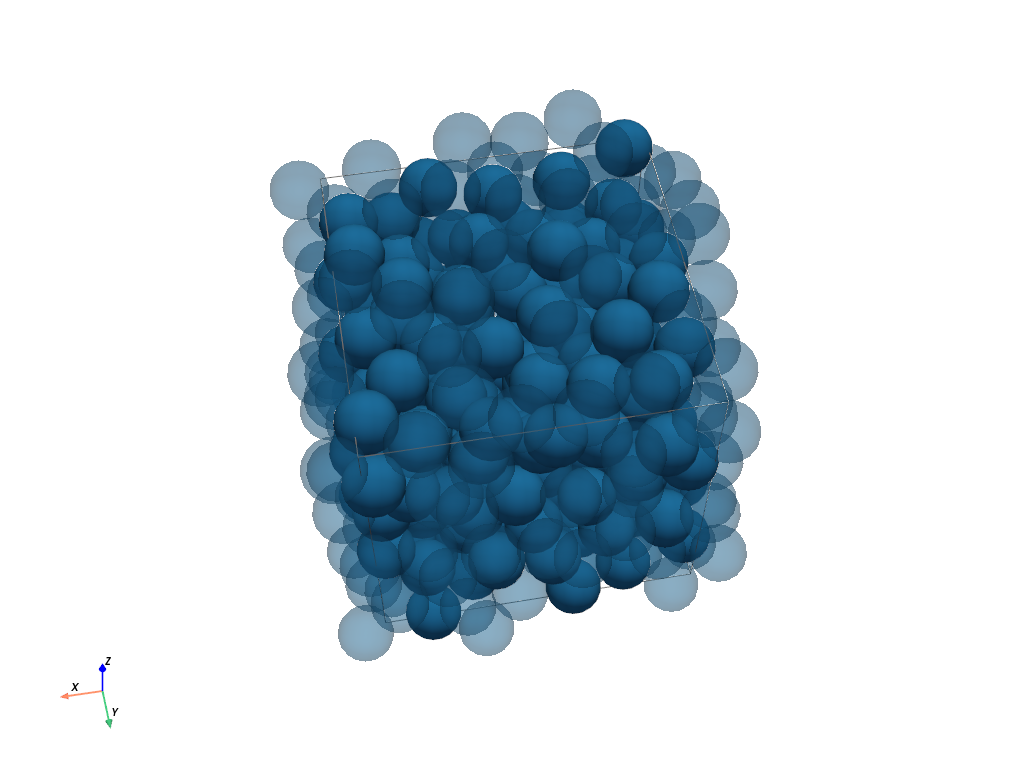

In [4]:
box = Box(
    rs=[1.0],
    vfs=[0.60],
    Nt=200,
)
box.generate_particles(method="FBR")
print(box)
box.plot(backend="pyvista").show()

The radial distribution $g(r)$ can be computed using the corresponding method.

In [5]:
gr = box.radial_distribution(5.0)

Text(0, 0.5, '$g(r)$')

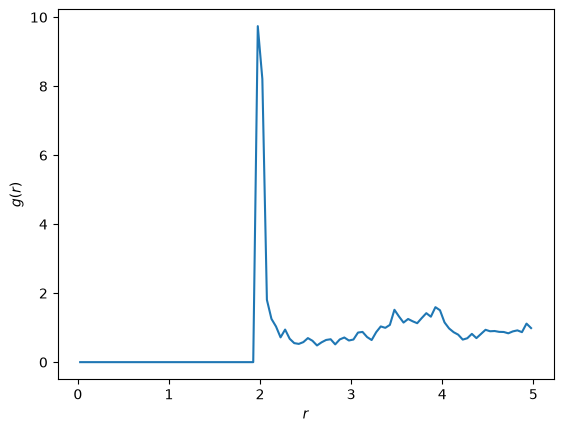

In [6]:
fig, ax = plt.subplots()
ax.plot(gr[0], gr[1])
ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$g(r)$")

## Random Multimodal Configurations

Random multimodal particle configurations can be generated with RSA (low density only) or FBR. Let's create a very dense bimodal packing with a size ratio of 1:5 and volume fractions of 50% and 20%, respectively.

Box(
    rs         = [1.  0.2],
    vfs_target = [0.5 0.2],
    vfs        = [0.51    0.19992],
    Nt_target  = 400,
    Nt         = 400,
    Ns         = [  8 392],
    length     = 4.035240961360873,
    method     = Force-Biased Relaxation,
    periodic   = True,
    success    = True,
)



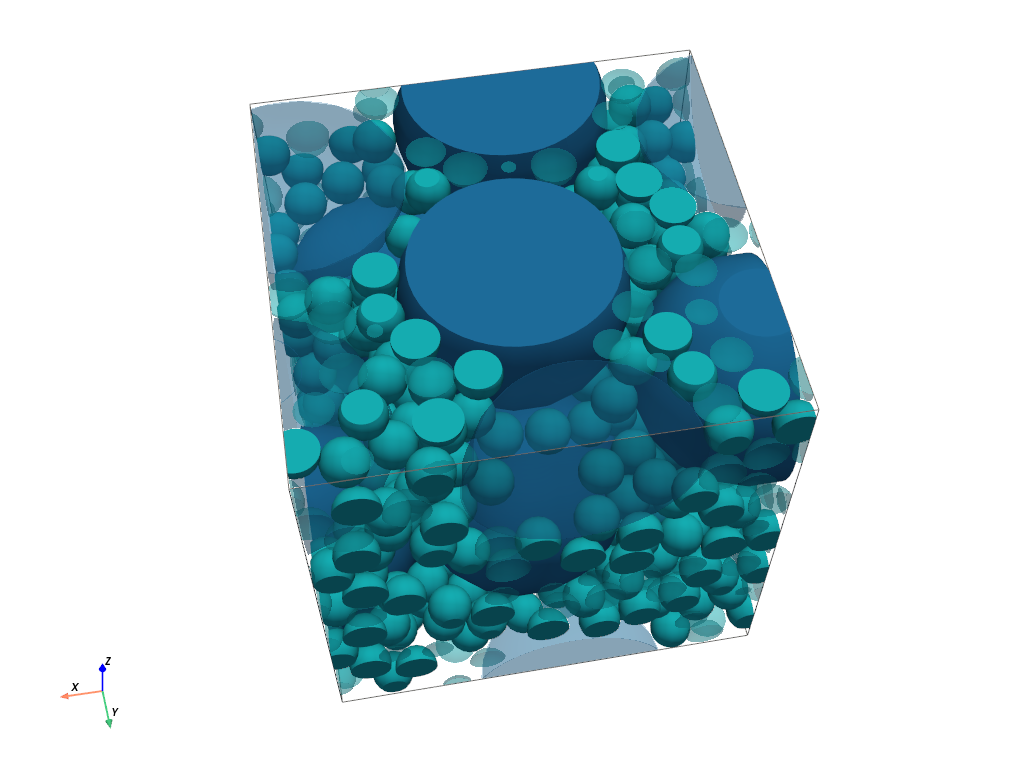

In [7]:
box = Box(
    rs=[1.0, 0.2],
    vfs=[0.50, 0.2],
    Nt=400,
)
box.generate_particles(method="FBR")
print(box)
box.plot(backend="pyvista", clip=True).show()

## Random Walk

One can simulate a random walk for any structure (lattice or random, mono- or multimodal). For ease of visualization, we consider a low-density packing.

In [8]:
box = Box(
    rs=[1.0, 0.2],
    vfs=[0.05, 0.01],
    Nt=100,
)
box.generate_particles(method="FBR")

True

In [9]:
walk = box.simulate_walk(D=1e-9)

In [10]:
walk.success

True

In [11]:
walk.time

338135710.6500946

In [12]:
walk.trajectory.shape

(32, 3)

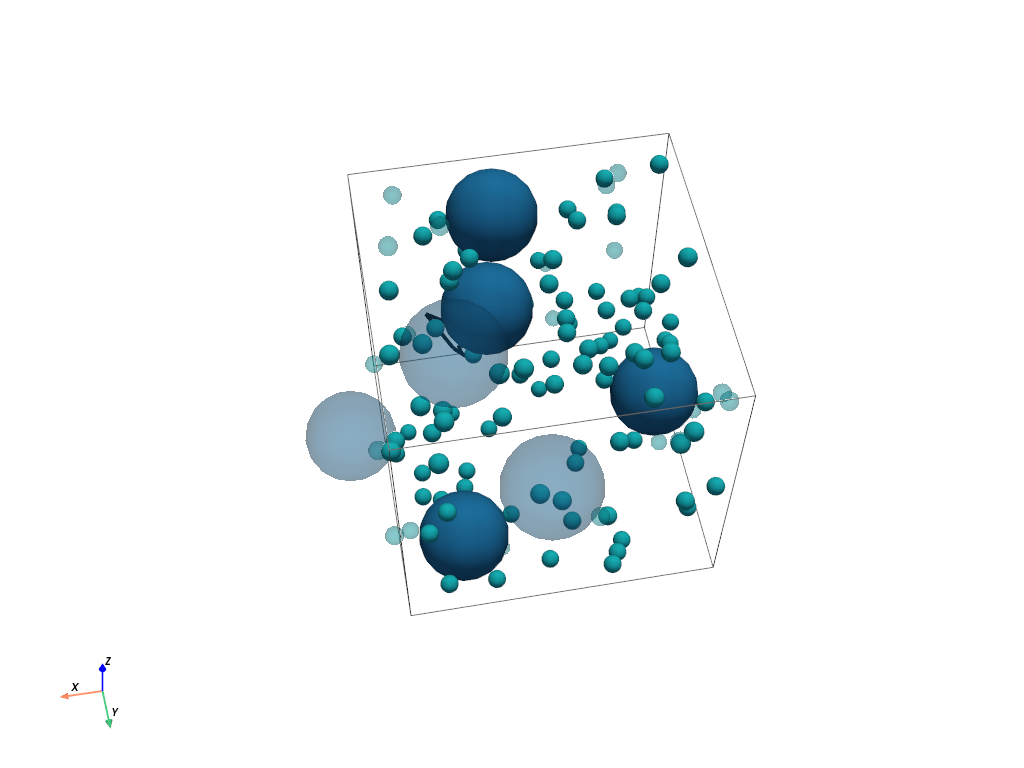

In [13]:
box.plot(walk=walk, backend="pyvista").show()